# Self-Sufficiency Navigator

**Author:** Viktoriia  
**Course:** DATA 205 — Capstone Experience in Data Science, Spring 2026  
**Instructor:** Prof. Lori A. Perine

## Project goal
Predict total personal income for Maryland working-age adults using IPUMS census microdata, compare it to the Self-Sufficiency Standard cost of living for Montgomery County, and recommend the highest-impact career and education changes to close the gap.

## Datasets
1. **Self-Sufficiency Standard for Maryland, 2023** — Dr. Diana Pearce, Center for Women's Welfare, University of Washington. Downloaded from selfsufficiencystandard.org.
2. **IPUMS USA (ACS Microdata)** — University of Minnesota, usa.ipums.org. Filtered to Maryland, 2023, working-age adults (18–64).
3. **BLS CPI and Employment Cost Index** — U.S. Bureau of Labor Statistics, bls.gov. To project 2023 SSS costs forward to 2026 and 2027.

## Approach
- **Pages 1–2 of the notebook**: data ingestion and cleaning.
- **Page 3**: exploratory analysis on the cleaned, filtered dataset.
- **Page 4**: XGBoost regression model to predict total personal income.
- **Page 5**: feature importance to identify which inputs the Streamlit app should ask users about.

In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
                                              0.0/294.9 kB ? eta -:--:--
     -------------------                    153.6/294.9 kB 4.5 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Import all needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import urllib.request 
import warnings 

#Display settings - make pandas output more readable
pd.set_option('display.max_columns',50)
pd.set_option('display.width',200)
warnings.filterwarnings('ignore') # silence harmless FutureWarnings

## 1. Self-Sufficiency Standard data
Source: The Self-Sufficiency Standard for Maryland, 2023 (selfsufficiencystandard.org). 
Downloaded as an Excel file. The "By Family" sheet contains 17,256 rows covering every combination of family composition × Maryland county.

In [3]:
# Download the SSS Excel file
import os
if not os.path.exists("MD2023_SSS.xlsx"):
    url = "https://selfsufficiencystandard.org/wp-content/uploads/2023/04/MD2023_SSS.xlsx"
    urllib.request.urlretrieve(url,"MD2023_SSS.xlsx")
    print("SSS file downloaded")
else:
    print("SSS file already on disk")

SSS file already on disk


In [4]:
#Load from the "By family" sheet
df_sss = pd.read_excel("MD2023_SSS.xlsx", sheet_name="By Family")

In [5]:
df_sss.columns = df_sss.columns.str.strip()

In [7]:
print("SSS shape: ",df_sss.shape)

SSS shape:  (17256, 26)


In [8]:
df_sss.head()

,Family Type,Adult(s),Infant(s),Preschooler(s),Schoolager(s),Teenager(s),State,Year,All Families Table #,County,Housing Costs,Child Care Costs,Food Costs,Transportation Costs,Health Care Costs,Miscellaneous costs,Broadband & Cell Phone,Other Necessities,Taxes,Earned Income Tax Credit (-),Child Care Tax Credit (-),Child Tax Credit (-),Hourly Self-Sufficiency Wage,Monthly Self-Sufficiency Wage,Annual Self-Sufficiency Wage,Emergency Savings
0,a1i0p0s0t0,1,0,0.0,0.0,0.0,MD,2023,1,Allegany County,669.90,0.00,322.18,394.36,245.81,274.38,111.15,163.22,575.25,0.00,0.0,0.00,14.10,2481.87,29782.44,67.27
1,a1i1p0s0t0,1,1,0.0,0.0,0.0,MD,2023,1,Allegany County,838.84,950.99,465.97,405.35,698.16,447.08,111.15,335.93,1146.51,0.00,-50.0,-166.67,26.91,4736.24,56834.88,226.76
2,a1i0p1s0t0,1,0,1.0,0.0,0.0,MD,2023,1,Allegany County,838.84,813.11,475.52,405.35,699.17,434.35,111.15,323.20,1083.84,0.00,-50.0,-166.67,25.76,4533.52,54402.21,210.51
3,a1i0p0s1t0,1,0,0.0,1.0,0.0,MD,2023,1,Allegany County,838.84,508.76,559.60,405.35,706.70,413.08,111.15,301.92,979.04,0.00,-50.0,-166.67,23.83,4194.69,50336.27,183.35
4,a1i0p0s0t1,1,0,0.0,0.0,1.0,MD,2023,1,Allegany County,838.84,0.00,588.18,394.36,733.95,366.68,111.15,255.53,690.27,-82.62,0.0,-166.67,19.11,3363.00,40355.98,126.18


## 2. IPUMS census microdata
Source: IPUMS USA, University of Minnesota. ACS microdata, filtered offline to:
- **Year 2023 only** (matches the SSS reference year)
- **Maryland residents** (STATEFIP == 24)
- **Working-age adults** (AGE 18–64)
- **Valid INCTOT values** (missing codes 9999999 and 9999998 dropped)

The filtered dataset has 28,077 rows × 63 columns and is saved as `ipums_md_2023.csv` (6.4 MB).

In [9]:
# Load the pre-filtered dataset
df = pd.read_csv("ipums_md_2023.csv")

In [10]:
# data verification
print("shape: ", df.shape)
print("Years: ", df["YEAR"].unique())
print("states:", df["STATEFIP"].unique())
print("Age range: ", df["AGE"].min(), "to ", df["AGE"].max())

shape:  (28077, 63)
Years:  [2023]
states: [24]
Age range:  18 to  55


## 3. Exploratory Data Analysis
### 3.1 Target Variable: total personal income (INCTOT)
INCTOT is total pre-tax personal income from all sources. The distribution is right-skewed, which is normal for income data. 

In [ ]:
# Drop INCTOT missing codes
df = df[~df["INCTOT"].isin([9999999, 9999998])].copy()

In [19]:
# Quick stats
print(df["INCTOT"].describe())
print(f"\nPeople with $0 income: {(df['INCTOT'] == 0).sum():,}")
print(f"People with negative income: {(df['INCTOT'] < 0).sum():,}")

count    2.807700e+04
mean     6.749166e+04
std      8.410947e+04
min     -8.600000e+03
25%      1.300000e+04
50%      4.800000e+04
75%      9.272000e+04
max      1.220000e+06
Name: INCTOT, dtype: float64

People with $0 income: 2,892
People with negative income: 33


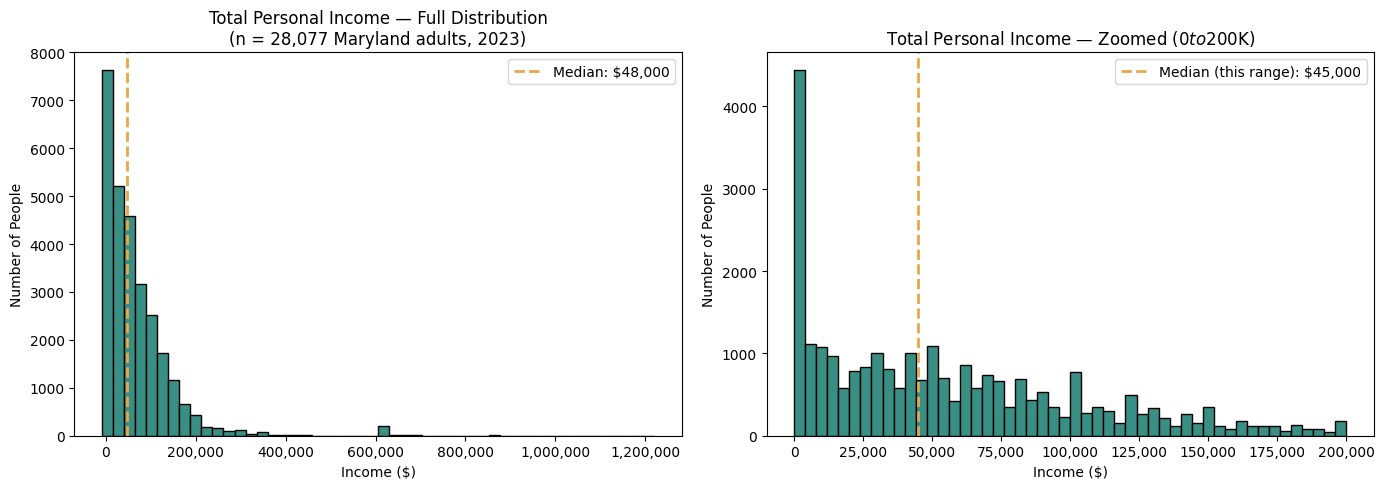

In [20]:
# Two-panel histogram: full range and zoomed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df["INCTOT"], bins=50, edgecolor='black', color='#3A8F85')
axes[0].axvline(df["INCTOT"].median(), color='#E8A848', linestyle='--', linewidth=2,
                label=f"Median: ${df['INCTOT'].median():,.0f}")
axes[0].set_title(f"Total Personal Income — Full Distribution\n(n = {len(df):,} Maryland adults, 2023)")
axes[0].set_xlabel("Income ($)")
axes[0].set_ylabel("Number of People")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].legend()

# Zoomed to 0-200k where most people actually live
sub = df[df["INCTOT"].between(0, 200000)]
axes[1].hist(sub["INCTOT"], bins=50, edgecolor='black', color='#3A8F85')
axes[1].axvline(sub["INCTOT"].median(), color='#E8A848', linestyle='--', linewidth=2,
                label=f"Median (this range): ${sub['INCTOT'].median():,.0f}")
axes[1].set_title("Total Personal Income — Zoomed ($0 to $200K)")
axes[1].set_xlabel("Income ($)")
axes[1].set_ylabel("Number of People")
axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Income vs. key features
Hypothesis: education and hours worked per week will be the strongest predictors of income. Let's check visually before modeling.

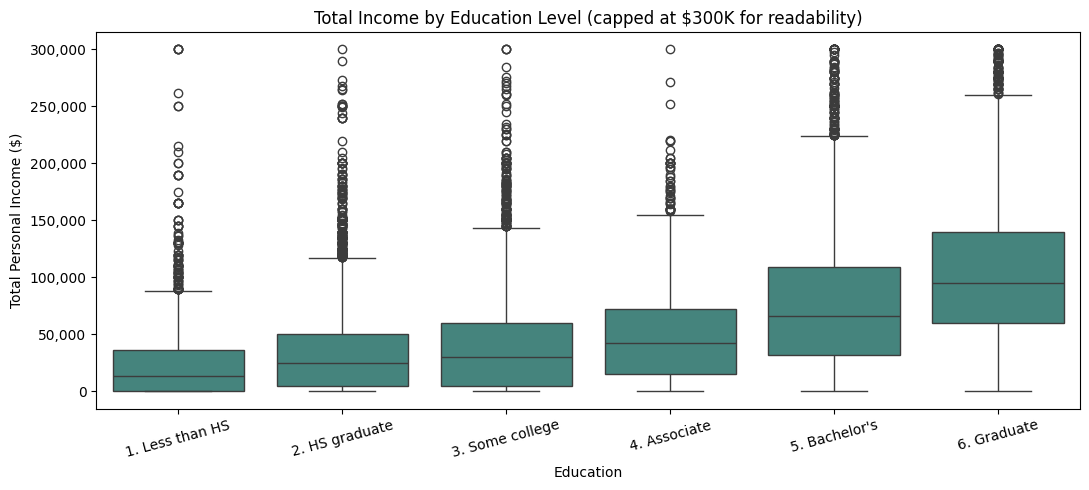

In [21]:
# Income by education level (EDUCD has many codes — group into broader bins)
# Common IPUMS EDUCD groupings:
#   <62  = less than high school
#   62-64 = high school graduate
#   65-71 = some college
#   81    = associate degree
#   101   = bachelor's degree
#   114-116 = graduate degree
def educ_group(code):
    if code < 62:    return "1. Less than HS"
    elif code <= 64: return "2. HS graduate"
    elif code <= 71: return "3. Some college"
    elif code == 81: return "4. Associate"
    elif code <= 101: return "5. Bachelor's"
    else:            return "6. Graduate"

df["educ_level"] = df["EDUCD"].apply(educ_group)

fig, ax = plt.subplots(figsize=(11, 5))
order = sorted(df["educ_level"].unique())
sns.boxplot(data=df[df["INCTOT"].between(0, 300000)], x="educ_level", y="INCTOT", 
            order=order, color='#3A8F85', ax=ax)
ax.set_title("Total Income by Education Level (capped at $300K for readability)")
ax.set_xlabel("Education")
ax.set_ylabel("Total Personal Income ($)")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

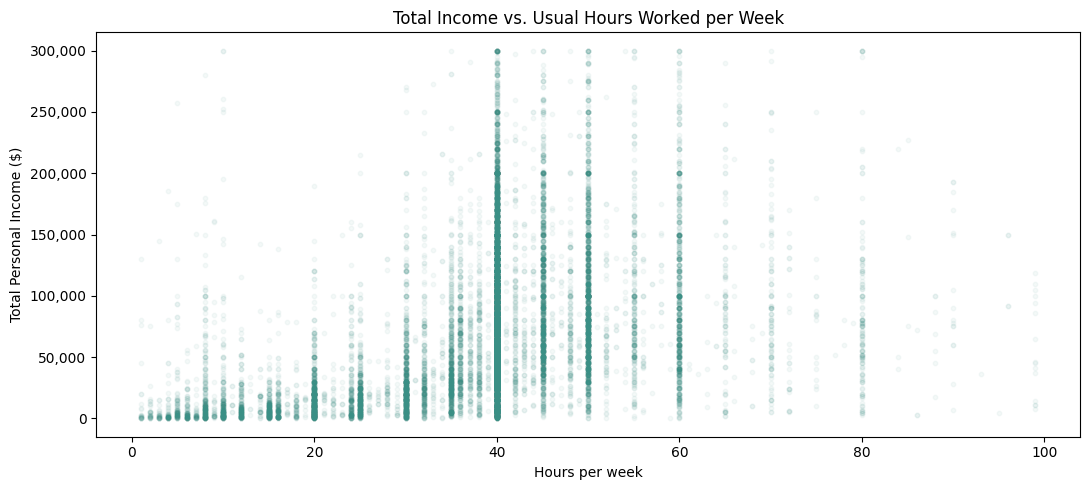

In [22]:
# Income by hours worked per week
# UHRSWORK = 0 means did not work — separate them out
fig, ax = plt.subplots(figsize=(11, 5))
worked = df[(df["UHRSWORK"] > 0) & (df["INCTOT"].between(0, 300000))]
ax.scatter(worked["UHRSWORK"], worked["INCTOT"], alpha=0.05, s=10, color='#3A8F85')
ax.set_title("Total Income vs. Usual Hours Worked per Week")
ax.set_xlabel("Hours per week")
ax.set_ylabel("Total Personal Income ($)")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

In [23]:
print(len(dir(plt)))

272


In [24]:
df.columns.to_list()

['YEAR',
 'SAMPLE',
 'SERIAL',
 'CBSERIAL',
 'HHWT',
 'CLUSTER',
 'STATEFIP',
 'PUMA',
 'METRO',
 'METAREA',
 'METAREAD',
 'CITY',
 'STRATA',
 'GQ',
 'PERNUM',
 'PERWT',
 'FAMSIZE',
 'NCHILD',
 'NCHLT5',
 'ELDCH',
 'YNGCH',
 'RELATE',
 'RELATED',
 'SEX',
 'AGE',
 'MARST',
 'MARRNO',
 'RACE',
 'RACED',
 'HISPAN',
 'HISPAND',
 'BPL',
 'BPLD',
 'CITIZEN',
 'YRIMMIG',
 'YRSUSA1',
 'YRSUSA2',
 'LANGUAGE',
 'LANGUAGED',
 'SPEAKENG',
 'EDUC',
 'EDUCD',
 'GRADEATT',
 'GRADEATTD',
 'DEGFIELD',
 'DEGFIELDD',
 'EMPSTAT',
 'EMPSTATD',
 'LABFORCE',
 'CLASSWKR',
 'CLASSWKRD',
 'OCC',
 'OCCSOC',
 'IND',
 'WKSWORK2',
 'UHRSWORK',
 'LOOKING',
 'INCTOT',
 'FTOTINC',
 'INCWAGE',
 'INCEARN',
 'POVERTY',
 'PWSTATE2',
 'educ_level']